In [64]:
import numpy as np
import matplotlib.pyplot as plt
import scipy
from scipy.ndimage import gaussian_filter
import pandas as pd
import scipy.optimize
import math
import matplotlib
matplotlib.rcParams['pdf.fonttype'] = 42

def weighted_avg_and_std(values, weights):
    """
    Return the weighted average and standard deviation.

    They weights are in effect first normalized so that they 
    sum to 1 (and so they must not all be 0).

    values, weights -- NumPy ndarrays with the same shape.
    """
    average = np.average(values, weights=weights)
    # Fast and numerically precise:
    variance = np.average((values-average)**2, weights=weights)
    return (average, math.sqrt(variance))

# read_colvar function which sorts colvar for unique entries from the back (i.e., second entry retained)
def read_colvar(colvar_file):

    data = np.loadtxt(colvar_file)
    # inverse order
    data = data[::-1]
    unique_idxs = np.array(np.unique(data[:,0], return_index=True)[1]).astype(int)[::-1] # find unique indices, first occurences
    data = data[unique_idxs]
    # original order
    data = data[::-1]

    return data


path = '/Volumes/Elements/PTM_project/PARK7/repeat_TYR_COORD_METAD_chainA_BF40/DATA_PLUMED/'

/Users/olivierstreit/miniconda3/lib/python3.7/site-packages/ipykernel_launcher.py:31: RuntimeWarning: divide by zero encountered in log


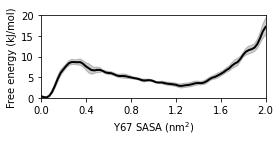

In [45]:
# average 1D FELs from the triplicates

nsims=3

# time course convergence
T=298

times = np.arange(220,1020,20)
t=times[-1] # at 1000ns, discarding first 200


xedges = np.arange(0,2.525,0.025)

fel_data = []

for s in range(1,nsims+1):
    data = read_colvar(path+'COLVAR.{}'.format(s))[::4] # 20ps
    CV = np.loadtxt(path+'../RMSD_SASA_data/sasa_chainA_TYR67_{}.xvg'.format(s),skiprows=25)[:,2]
    rbias = data[:,4]
    frame = int(t*1000/20)
    init_frame = int((times[0]-(times[1]-times[0]))*1000/20)
    
    # FEL rbias reweighting
    kbt = 0.008314*T
    weights = np.exp((rbias[init_frame:frame]-np.amax(rbias[init_frame:frame]))/kbt)
    weights = weights/np.sum(weights)
    
    
    hist,x = np.histogram(CV[init_frame:frame],weights=weights,bins=xedges)
    p = hist/np.sum(hist)
    fel = -kbt*np.log(p)
    fel = scipy.ndimage.gaussian_filter(fel,sigma=1)
    fel = fel-np.min(fel)
    fel_data.append(fel)
    
# average and error
fel_data = np.array(fel_data)
mu = np.mean(fel_data,axis=0)
err = np.std(fel_data,axis=0)/np.sqrt(nsims)

plt.figure(figsize = (4,2))


plt.plot(x[:-1],mu,color = 'black',linewidth=2)
plt.fill_between(x[:-1],mu-err,mu+err,color = 'black',alpha = 0.2)
    
# formatting

plt.xlabel('Y67 SASA (nm$^{2}$)')
plt.xlim(0,2.)
plt.xticks(ticks=np.array([0,0.2,0.4,0.6,0.8,1.0])*2.,labels=np.array([0,0.2,0.4,0.6,0.8,1.0])*2.)
plt.ylabel('Free energy (kJ/mol)')
plt.ylim(0,20)
#plt.axvline(0.35)

plt.tight_layout()
plt.savefig('1D_avgFEL_SASA.pdf')

<Figure size 288x216 with 0 Axes>

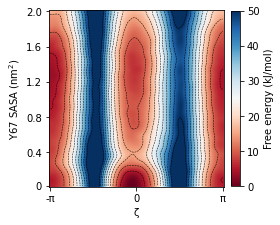

In [46]:
# with rbias reweighting 

nsims=3
T = 298

t= 1000
t_discard = 200

h_dat = []
for sim in range(1,nsims+1):
    data = read_colvar(path+'COLVAR.{}'.format(sim))[::4] # 20 ps
    zeta = data[:,1]
    SASA = np.loadtxt(path+'../RMSD_SASA_data/sasa_chainA_TYR67_{}.xvg'.format(sim),skiprows=25)[:,2]
    rbias = data[:,4]

    xedges = np.arange(-np.pi,np.pi,2*np.pi/100)
    yedges = np.arange(0,2.02,0.02)

    frame = int(t*1000/20)
    init_frame = int(t_discard*1000/20)

    # FEL rbias reweighting
    kbt = 0.008314*T

    


    weights = np.exp((rbias[init_frame:frame]-np.amax(rbias[init_frame:frame]))/kbt)
    weights = weights/np.sum(weights)

    x=zeta[init_frame:frame]
    y=SASA[init_frame:frame]

    H, xedges, yedges = np.histogram2d(x, y, weights=weights,bins=(xedges,yedges)) # H = counts per bin
    H = gaussian_filter(H, sigma=2)
    h = H/np.sum(H) # convert counts to probility
    h = -kbt*np.log(h) # calculate free energy from probability
    h = h-np.min(h) # set minimum to 0 kbT
    h = h.T
    h_dat.append(h)

h_dat = np.array(h_dat)
h_mu = np.mean(h_dat,axis=0)
h_err = np.std(h_dat,axis=0)/np.sqrt(nsims)
h_mu = np.nan_to_num(h_mu,posinf=100)

plt.figure(figsize = (4,3))
max_energy = 50
from scipy.ndimage.filters import gaussian_filter
plt.figure(figsize = (4,4))
filtered_arr=gaussian_filter(h_mu, sigma=0.1)
plt.imshow(filtered_arr,origin='lower',cmap='RdBu')
plt.clim(0,max_energy)
plt.colorbar(fraction=0.046, pad=0.04,label = 'Free energy (kJ/mol)')
xlabels = ['-\u03C0',0,'\u03C0']
ylabels = [0,0.4,0.8,1.2,1.6,2.0]
plt.xticks(ticks = [0,49,98],labels =xlabels)
plt.yticks(ticks = [0,19,39,59,79,99],labels =ylabels)

# contours
#plt.contour(filtered_arr,levels = np.arange(0,19,1),colors = np.repeat(str('black'),18),
                #linewidths = np.repeat(0.5,18), linestyles = np.repeat(str('dashed'),18))

plt.contour(filtered_arr,levels = np.arange(0,max_energy+5,5),colors = np.repeat(str('black'),max_energy*2),
                linewidths = np.repeat(0.5,max_energy*2), linestyles = np.repeat(str('dashed'),max_energy*2))
#plt.title('Average')
plt.xlabel('\u03B6')
plt.ylabel('Y67 SASA (nm$^{2}$)')

plt.tight_layout()
plt.savefig('Avg_2D_zeta_vs_SASA.pdf')

<Figure size 288x216 with 0 Axes>

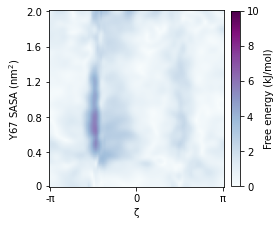

In [47]:
# with rbias reweighting 

nsims=3
T = 298

t= 1000
t_discard = 200

h_dat = []
for sim in range(1,nsims+1):
    data = read_colvar(path+'COLVAR.{}'.format(sim))[::4] # 20 ps
    zeta = data[:,1]
    SASA = np.loadtxt(path+'../RMSD_SASA_data/sasa_chainA_TYR67_{}.xvg'.format(sim),skiprows=25)[:,2]
    rbias = data[:,4]

    xedges = np.arange(-np.pi,np.pi,2*np.pi/100)
    yedges = np.arange(0,2.02,0.02)

    frame = int(t*1000/20)
    init_frame = int(t_discard*1000/20)

    # FEL rbias reweighting
    kbt = 0.008314*T

    


    weights = np.exp((rbias[init_frame:frame]-np.amax(rbias[init_frame:frame]))/kbt)
    weights = weights/np.sum(weights)

    x=zeta[init_frame:frame]
    y=SASA[init_frame:frame]

    H, xedges, yedges = np.histogram2d(x, y, weights=weights,bins=(xedges,yedges)) # H = counts per bin
    H = gaussian_filter(H, sigma=2)
    h = H/np.sum(H) # convert counts to probility
    h = -kbt*np.log(h) # calculate free energy from probability
    h = h-np.min(h) # set minimum to 0 kbT
    h = h.T
    h_dat.append(h)

h_dat = np.array(h_dat)
h_mu = np.mean(h_dat,axis=0)
h_err = np.std(h_dat,axis=0)/np.sqrt(nsims)
h_mu = np.nan_to_num(h_mu,posinf=100)

plt.figure(figsize = (4,3))
max_energy = 10
from scipy.ndimage.filters import gaussian_filter
plt.figure(figsize = (4,4))
filtered_arr=gaussian_filter(h_err, sigma=0.1)
plt.imshow(filtered_arr,origin='lower',cmap='BuPu')
plt.clim(0,max_energy)
plt.colorbar(fraction=0.046, pad=0.04,label = 'Free energy (kJ/mol)')
xlabels = ['-\u03C0',0,'\u03C0']
ylabels = [0,0.4,0.8,1.2,1.6,2.0]
plt.xticks(ticks = [0,49,98],labels =xlabels)
plt.yticks(ticks = [0,19,39,59,79,99],labels =ylabels)

# contours
#plt.contour(filtered_arr,levels = np.arange(0,19,1),colors = np.repeat(str('black'),18),
                #linewidths = np.repeat(0.5,18), linestyles = np.repeat(str('dashed'),18))

#plt.contour(filtered_arr,levels = np.arange(0,max_energy+5,5),colors = np.repeat(str('black'),max_energy*2),
                #linewidths = np.repeat(0.5,max_energy*2), linestyles = np.repeat(str('dashed'),max_energy*2))
#plt.title('Average')
plt.xlabel('\u03B6')
plt.ylabel('Y67 SASA (nm$^{2}$)')

plt.tight_layout()
plt.savefig('Err_2D_zeta_vs_SASA.pdf')

In [48]:
## calculate average SASA in cis and in trans state
# calculate average fraction cis

# average 1D FELs from the triplicates

nsims=3

# time course convergence
T=298

times = np.arange(220,1020,20)
t=times[-1] # at 1000ns, discarding first 200


cis_SASA = []
trans_SASA = []

for s in range(1,nsims+1):
    data = read_colvar(path+'COLVAR.{}'.format(s))[::4] # 20 ps
    CV = data[:,1]
    SASA = np.loadtxt(path+'../RMSD_SASA_data/sasa_chainA_TYR67_{}.xvg'.format(s),skiprows=25)[:,2]
    rbias = data[:,4]
    frame = int(t*1000/20)
    init_frame = int((times[0]-(times[1]-times[0]))*1000/20)
    
    # FEL rbias reweighting
    kbt = 0.008314*T
    weights = np.exp((rbias[init_frame:frame]-np.amax(rbias[init_frame:frame]))/kbt)
    weights = weights/np.sum(weights)
    
    
    cisframes = np.where(np.abs(CV[init_frame:frame])<1.4)[0] # abs zeta angle less than ~80 deg
    transframes = np.where(np.abs(CV[init_frame:frame])>1.4)[0] # abs zeta angle more than ~80 deg
    
    cis_SASA.append(np.average(SASA[init_frame:frame][cisframes],weights=weights[cisframes]))
    trans_SASA.append(np.average(SASA[init_frame:frame][transframes],weights=weights[transframes]))
    
# average and error

mu_cis = np.round(np.mean(cis_SASA),2)
err_cis = np.round(np.std(cis_SASA)/np.sqrt(nsims),2)

mu_trans = np.round(np.mean(trans_SASA),2)
err_trans = np.round(np.std(trans_SASA)/np.sqrt(nsims),2)

df = pd.DataFrame()
df['Proline state'] = ['cis','trans']
df['Avg SASA (nm^2)'] = [mu_cis,mu_trans]
df['Error']  = [err_cis,err_trans]
df.to_csv('avg_SASA_proline_states.csv')
df

,Proline state,Avg SASA (nm^2),Error
0,cis,0.42,0.05
1,trans,0.97,0.07


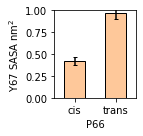

In [65]:
# plot
df = pd.read_csv('avg_SASA_proline_states.csv')
df.plot(x='Proline state',y='Avg SASA (nm^2)',yerr= np.array(df['Error']),
       kind='bar',figsize = (2,2),legend=False,color = '#FEC89A',edgecolor = 'black',
       capsize = 2)

plt.xticks(rotation=0)
plt.ylim(0,1)
plt.xlabel('P66')

plt.ylabel('Y67 SASA nm$^{2}$')

plt.tight_layout()
plt.savefig('Y67_SASA_proline_states_barplot.pdf')

In [50]:
# calculate average SASA in cis and in trans state
# calculate average fraction open

# average 1D FELs from the triplicates

nsims=3

# time course convergence
T=298

times = np.arange(220,1020,20)
t=times[-1] # at 1000ns, discarding first 200


cis_SASA = []
trans_SASA = []

for s in range(1,nsims+1):
    data = read_colvar(path+'COLVAR.{}'.format(s))[::4] # 20 ps
    CV = data[:,1]
    SASA = np.loadtxt(path+'../RMSD_SASA_data/sasa_chainA_TYR67_{}.xvg'.format(s),skiprows=25)[:,2]
    rbias = data[:,4]
    frame = int(t*1000/20)
    init_frame = int((times[0]-(times[1]-times[0]))*1000/20)
    
    # FEL rbias reweighting
    kbt = 0.008314*T
    weights = np.exp((rbias[init_frame:frame]-np.amax(rbias[init_frame:frame]))/kbt)
    weights = weights/np.sum(weights)
    
    
    cisframes = np.where(np.abs(CV[init_frame:frame])<1.4)[0] # abs zeta angle less than ~80 deg
    transframes = np.where(np.abs(CV[init_frame:frame])>1.4)[0] # abs zeta angle more than ~80 deg
    
    cis_SASA.append(np.average((SASA[init_frame:frame][cisframes]>0.35)*1,weights=weights[cisframes]))
    trans_SASA.append(np.average((SASA[init_frame:frame][transframes]>0.35)*1,weights=weights[transframes]))
    
# average and error

mu_cis = np.round(np.mean(cis_SASA),2)
err_cis = np.round(np.std(cis_SASA)/np.sqrt(nsims),2)

mu_trans = np.round(np.mean(trans_SASA),2)
err_trans = np.round(np.std(trans_SASA)/np.sqrt(nsims),2)

df = pd.DataFrame()
df['Proline state'] = ['cis','trans']
df['Avg % open'] = [mu_cis,mu_trans]
df['Error']  = [err_cis,err_trans]
df.to_csv('avg_open_population_proline_states.csv')
df

,Proline state,Avg % open,Error
0,cis,0.31,0.06
1,trans,0.85,0.03


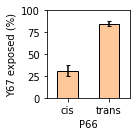

In [51]:
# plot
df = pd.read_csv('avg_open_population_proline_states.csv')
df['Avg % open']=df['Avg % open']*100
df['Error']=df['Error']*100
df.plot(x='Proline state',y='Avg % open',yerr= np.array(df['Error']),
       kind='bar',figsize = (2,2),legend=False,color = '#FEC89A',edgecolor = 'black',
       capsize = 2)

plt.xticks(rotation=0)
plt.ylim(0,100)
plt.xlabel('P66')

plt.ylabel('Y67 exposed (%)')

plt.tight_layout()
plt.savefig('Y67_percent_exposed_proline_states_barplot.pdf')

In [61]:
# calculate cis/trans populations in Y67 exposed vs buried

# average 1D FELs from the triplicates

nsims=3

# time course convergence
T=298

times = np.arange(220,1020,20)
t=times[-1] # at 1000ns, discarding first 200



buried_cis = []
exposed_cis = []

for s in range(1,nsims+1):
    data = read_colvar(path+'COLVAR.{}'.format(s))[::4] # 20 ps
    CV = data[:,1]
    SASA = np.loadtxt(path+'../RMSD_SASA_data/sasa_chainA_TYR67_{}.xvg'.format(s),skiprows=25)[:,2]
    rbias = data[:,4]
    frame = int(t*1000/20)
    init_frame = int((times[0]-(times[1]-times[0]))*1000/20)
    
    # FEL rbias reweighting
    kbt = 0.008314*T
    weights = np.exp((rbias[init_frame:frame]-np.amax(rbias[init_frame:frame]))/kbt)
    weights = weights/np.sum(weights)
    
    buried_frames = np.where(SASA[init_frame:frame]<0.35)[0]
    exposed_frames = np.where(SASA[init_frame:frame]>0.35)[0]
    
    buried_cis.append(np.average((np.abs(CV[init_frame:frame][buried_frames])<1.4)*1, weights=weights[buried_frames]))
    exposed_cis.append(np.average((np.abs(CV[init_frame:frame][exposed_frames])<1.4)*1, weights=weights[exposed_frames]))
    
# average and error

mu_buried = np.round(np.mean(buried_cis),2)
err_buried = np.round(np.std(buried_cis)/np.sqrt(nsims),2)

mu_exposed = np.round(np.mean(exposed_cis),2)
err_exposed = np.round(np.std(exposed_cis)/np.sqrt(nsims),2)

df = pd.DataFrame()
df['Y67 state'] = ['buried','exposed']
df['% P66 cis'] = [mu_buried,mu_exposed]
df['Error']  = [err_buried,err_exposed]
df.to_csv('avg_cis_TYR67_state.csv')
df

,Y67 state,% P66 cis,Error
0,buried,0.77,0.02
1,exposed,0.20,0.03


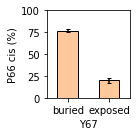

In [58]:
# plot
df = pd.read_csv('avg_cis_TYR67_state.csv')
df['% P66 cis']=df['% P66 cis']*100
df['Error']=df['Error']*100
df.plot(x='Y67 state',y='% P66 cis',yerr= np.array(df['Error']),
       kind='bar',figsize = (2,2),legend=False,color = '#FEC89A',edgecolor = 'black',
       capsize = 2)

plt.xticks(rotation=0)
plt.ylim(0,100)
plt.xlabel('Y67')

plt.ylabel('P66 cis (%)')

plt.tight_layout()
plt.savefig('P66_cis_population_Y67_states_barplot.pdf')

In [28]:
# COMPARISON WITH FINAL BIAS

/Users/olivierstreit/miniconda3/lib/python3.7/site-packages/ipykernel_launcher.py:29: RuntimeWarning: divide by zero encountered in log


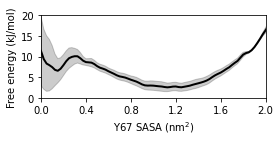

In [32]:
# average 1D FELs from the triplicates

nsims=3

# time course convergence
T=300

t=1000


xedges = np.arange(0,2.525,0.025)

fel_data = []

for s in range(1,nsims+1):
    data = np.loadtxt(path+'../final_bias_from_hills_1us/COLVAR_REW.{}'.format(s))
    CV = np.loadtxt(path+'../RMSD_SASA_data/sasa_chainA_TYR67_{}.xvg'.format(s),skiprows=25)[:,2]
    rbias = data[:,4]
    frame = int(t*1000/20)
    
    # FEL rbias reweighting
    kbt = 0.008314*T
    weights = np.exp((rbias[:frame]-np.amax(rbias[:frame]))/kbt)
    weights = weights/np.sum(weights)
    
    
    hist,x = np.histogram(CV[:frame],weights=weights,bins=xedges)
    p = hist/np.sum(hist)
    fel = -kbt*np.log(p)
    fel = scipy.ndimage.gaussian_filter(fel,sigma=1)
    fel = fel-np.min(fel)
    fel_data.append(fel)
    
# average and error
fel_data = np.array(fel_data)
mu = np.mean(fel_data,axis=0)
err = np.std(fel_data,axis=0)/np.sqrt(nsims)

plt.figure(figsize = (4,2))


plt.plot(x[:-1],mu,color = 'black',linewidth=2)
plt.fill_between(x[:-1],mu-err,mu+err,color = 'black',alpha = 0.2)
    
# formatting

plt.xlabel('Y67 SASA (nm$^{2}$)')
plt.xlim(0,2.)
plt.xticks(ticks=np.array([0,0.2,0.4,0.6,0.8,1.0])*2.,labels=np.array([0,0.2,0.4,0.6,0.8,1.0])*2.)
plt.ylabel('Free energy (kJ/mol)')
plt.ylim(0,20)
#plt.axvline(0.35)

plt.tight_layout()
plt.savefig('1D_avgFEL_SASA_finalbias.pdf')

<Figure size 288x216 with 0 Axes>

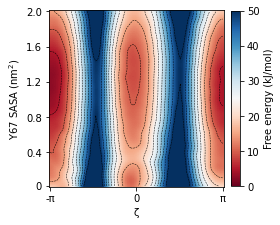

In [33]:
# with rbias reweighting 

nsims=3
T = 300

t= 1000
t_discard = 200

h_dat = []
for sim in range(1,nsims+1):
    data = np.loadtxt(path+'../final_bias_from_hills_1us/COLVAR_REW.{}'.format(sim))
    zeta = data[:,1]
    SASA = np.loadtxt(path+'../RMSD_SASA_data/sasa_chainA_TYR67_{}.xvg'.format(sim),skiprows=25)[:,2]
    rbias = data[:,4]

    xedges = np.arange(-np.pi,np.pi,2*np.pi/100)
    yedges = np.arange(0,2.02,0.02)

    frame = int(t*1000/20)
    init_frame = int(t_discard*1000/20)

    # FEL rbias reweighting
    kbt = 0.008314*T

    


    weights = np.exp((rbias[init_frame:frame]-np.amax(rbias[init_frame:frame]))/kbt)
    weights = weights/np.sum(weights)

    x=zeta[init_frame:frame]
    y=SASA[init_frame:frame]

    H, xedges, yedges = np.histogram2d(x, y, weights=weights,bins=(xedges,yedges)) # H = counts per bin
    H = gaussian_filter(H, sigma=2)
    h = H/np.sum(H) # convert counts to probility
    h = -kbt*np.log(h) # calculate free energy from probability
    h = h-np.min(h) # set minimum to 0 kbT
    h = h.T
    h_dat.append(h)

h_dat = np.array(h_dat)
h_mu = np.mean(h_dat,axis=0)
h_err = np.std(h_dat,axis=0)/np.sqrt(nsims)
h_mu = np.nan_to_num(h_mu,posinf=100)

plt.figure(figsize = (4,3))
max_energy = 50
from scipy.ndimage.filters import gaussian_filter
plt.figure(figsize = (4,4))
filtered_arr=gaussian_filter(h_mu, sigma=0.1)
plt.imshow(filtered_arr,origin='lower',cmap='RdBu')
plt.clim(0,max_energy)
plt.colorbar(fraction=0.046, pad=0.04,label = 'Free energy (kJ/mol)')
xlabels = ['-\u03C0',0,'\u03C0']
ylabels = [0,0.4,0.8,1.2,1.6,2.0]
plt.xticks(ticks = [0,49,98],labels =xlabels)
plt.yticks(ticks = [0,19,39,59,79,99],labels =ylabels)

# contours
#plt.contour(filtered_arr,levels = np.arange(0,19,1),colors = np.repeat(str('black'),18),
                #linewidths = np.repeat(0.5,18), linestyles = np.repeat(str('dashed'),18))

plt.contour(filtered_arr,levels = np.arange(0,max_energy+5,5),colors = np.repeat(str('black'),max_energy*2),
                linewidths = np.repeat(0.5,max_energy*2), linestyles = np.repeat(str('dashed'),max_energy*2))
#plt.title('Average')
plt.xlabel('\u03B6')
plt.ylabel('Y67 SASA (nm$^{2}$)')

plt.tight_layout()
plt.savefig('Avg_2D_zeta_vs_SASA_finalbias.pdf')

In [34]:
## calculate average SASA in cis and in trans state
# calculate average fraction cis

# average 1D FELs from the triplicates

nsims=3

# time course convergence
T=300

times = np.arange(220,1020,20)
t=times[-1] # at 1000ns, discarding first 200


cis_SASA = []
trans_SASA = []

for s in range(1,nsims+1):
    data = np.loadtxt(path+'../final_bias_from_hills_1us/COLVAR_REW.{}'.format(s))
    CV = data[:,1]
    SASA = np.loadtxt(path+'../RMSD_SASA_data/sasa_chainA_TYR67_{}.xvg'.format(s),skiprows=25)[:,2]
    rbias = data[:,4]
    frame = int(t*1000/20)
    init_frame = int((times[0]-(times[1]-times[0]))*1000/20)
    
    # FEL rbias reweighting
    kbt = 0.008314*T
    weights = np.exp((rbias[init_frame:frame]-np.amax(rbias[init_frame:frame]))/kbt)
    weights = weights/np.sum(weights)
    
    
    cisframes = np.where(np.abs(CV[init_frame:frame])<1.4)[0] # abs zeta angle less than ~80 deg
    transframes = np.where(np.abs(CV[init_frame:frame])>1.4)[0] # abs zeta angle more than ~80 deg
    
    cis_SASA.append(np.average(SASA[init_frame:frame][cisframes],weights=weights[cisframes]))
    trans_SASA.append(np.average(SASA[init_frame:frame][transframes],weights=weights[transframes]))
    
# average and error

mu_cis = np.round(np.mean(cis_SASA),2)
err_cis = np.round(np.std(cis_SASA)/np.sqrt(nsims),2)

mu_trans = np.round(np.mean(trans_SASA),2)
err_trans = np.round(np.std(trans_SASA)/np.sqrt(nsims),2)

df = pd.DataFrame()
df['Proline state'] = ['cis','trans']
df['Avg SASA (nm^2)'] = [mu_cis,mu_trans]
df['Error']  = [err_cis,err_trans]
df.to_csv('avg_SASA_proline_states_finalbias.csv')
df

,Proline state,Avg SASA (nm^2),Error
0,cis,0.69,0.26
1,trans,0.96,0.12


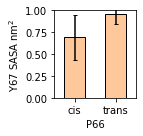

In [66]:
# plot
df = pd.read_csv('avg_SASA_proline_states_finalbias.csv')
df.plot(x='Proline state',y='Avg SASA (nm^2)',yerr= np.array(df['Error']),
       kind='bar',figsize = (2,2),legend=False,color = '#FEC89A',edgecolor = 'black',
       capsize = 2)

plt.xticks(rotation=0)
plt.ylim(0,1)
plt.xlabel('P66')

plt.ylabel('Y67 SASA nm$^{2}$')

plt.tight_layout()
plt.savefig('Y67_SASA_proline_states_barplot_finalbias.pdf')

In [36]:
# calculate average SASA in cis and in trans state
# calculate average fraction open

# average 1D FELs from the triplicates

nsims=3

# time course convergence
T=298

times = np.arange(220,1020,20)
t=times[-1] # at 1000ns, discarding first 200


cis_SASA = []
trans_SASA = []

for s in range(1,nsims+1):
    data = np.loadtxt(path+'../final_bias_from_hills_1us/COLVAR_REW.{}'.format(s))
    CV = data[:,1]
    SASA = np.loadtxt(path+'../RMSD_SASA_data/sasa_chainA_TYR67_{}.xvg'.format(s),skiprows=25)[:,2]
    rbias = data[:,4]
    frame = int(t*1000/20)
    init_frame = int((times[0]-(times[1]-times[0]))*1000/20)
    
    # FEL rbias reweighting
    kbt = 0.008314*T
    weights = np.exp((rbias[init_frame:frame]-np.amax(rbias[init_frame:frame]))/kbt)
    weights = weights/np.sum(weights)
    
    
    cisframes = np.where(np.abs(CV[init_frame:frame])<1.4)[0] # abs zeta angle less than ~80 deg
    transframes = np.where(np.abs(CV[init_frame:frame])>1.4)[0] # abs zeta angle more than ~80 deg
    
    cis_SASA.append(np.average((SASA[init_frame:frame][cisframes]>0.35)*1,weights=weights[cisframes]))
    trans_SASA.append(np.average((SASA[init_frame:frame][transframes]>0.35)*1,weights=weights[transframes]))
    
# average and error

mu_cis = np.round(np.mean(cis_SASA),2)
err_cis = np.round(np.std(cis_SASA)/np.sqrt(nsims),2)

mu_trans = np.round(np.mean(trans_SASA),2)
err_trans = np.round(np.std(trans_SASA)/np.sqrt(nsims),2)

df = pd.DataFrame()
df['Proline state'] = ['cis','trans']
df['Avg % open'] = [mu_cis,mu_trans]
df['Error']  = [err_cis,err_trans]
df.to_csv('avg_open_population_proline_states_finalbias.csv')
df

,Proline state,Avg % open,Error
0,cis,0.57,0.21
1,trans,0.83,0.14


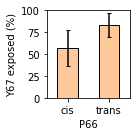

In [37]:
# plot
df = pd.read_csv('avg_open_population_proline_states_finalbias.csv')
df['Avg % open']=df['Avg % open']*100
df['Error']=df['Error']*100
df.plot(x='Proline state',y='Avg % open',yerr= np.array(df['Error']),
       kind='bar',figsize = (2,2),legend=False,color = '#FEC89A',edgecolor = 'black',
       capsize = 2)

plt.xticks(rotation=0)
plt.ylim(0,100)
plt.xlabel('P66')

plt.ylabel('Y67 exposed (%)')

plt.tight_layout()
plt.savefig('Y67_percent_exposed_proline_states_barplot_finalbias.pdf')

In [59]:
# calculate cis/trans populations in Y67 exposed vs buried

# average 1D FELs from the triplicates

nsims=3

# time course convergence
T=298

times = np.arange(220,1020,20)
t=times[-1] # at 1000ns, discarding first 200



buried_cis = []
exposed_cis = []

for s in range(1,nsims+1):
    data = np.loadtxt(path+'../final_bias_from_hills_1us/COLVAR_REW.{}'.format(s))
    CV = data[:,1]
    SASA = np.loadtxt(path+'../RMSD_SASA_data/sasa_chainA_TYR67_{}.xvg'.format(s),skiprows=25)[:,2]
    rbias = data[:,4]
    frame = int(t*1000/20)
    init_frame = int((times[0]-(times[1]-times[0]))*1000/20)
    
    # FEL rbias reweighting
    kbt = 0.008314*T
    weights = np.exp((rbias[init_frame:frame]-np.amax(rbias[init_frame:frame]))/kbt)
    weights = weights/np.sum(weights)
    
    buried_frames = np.where(SASA[init_frame:frame]<0.35)[0]
    exposed_frames = np.where(SASA[init_frame:frame]>0.35)[0]
    
    buried_cis.append(np.average((np.abs(CV[init_frame:frame][buried_frames])<1.4)*1, weights=weights[buried_frames]))
    exposed_cis.append(np.average((np.abs(CV[init_frame:frame][exposed_frames])<1.4)*1, weights=weights[exposed_frames]))
    
# average and error

mu_buried = np.round(np.mean(buried_cis),2)
err_buried = np.round(np.std(buried_cis)/np.sqrt(nsims),2)

mu_exposed = np.round(np.mean(exposed_cis),2)
err_exposed = np.round(np.std(exposed_cis)/np.sqrt(nsims),2)

df = pd.DataFrame()
df['Y67 state'] = ['buried','exposed']
df['% P66 cis'] = [mu_buried,mu_exposed]
df['Error']  = [err_buried,err_exposed]
df.to_csv('avg_cis_TYR67_state_finalbias.csv')
df

,Y67 state,% P66 cis,Error
0,buried,0.38,0.25
1,exposed,0.11,0.02


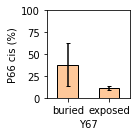

In [63]:
# plot
df = pd.read_csv('avg_cis_TYR67_state_finalbias.csv')
df['% P66 cis']=df['% P66 cis']*100
df['Error']=df['Error']*100
df.plot(x='Y67 state',y='% P66 cis',yerr= np.array(df['Error']),
       kind='bar',figsize = (2,2),legend=False,color = '#FEC89A',edgecolor = 'black',
       capsize = 2)

plt.xticks(rotation=0)
plt.ylim(0,100)
plt.xlabel('Y67')

plt.ylabel('P66 cis (%)')

plt.tight_layout()
plt.savefig('P66_cis_population_Y67_states_barplot_finalbias.pdf')